In [2]:
import os
import json
import numpy as np
from tqdm import tqdm
from scipy.stats import gaussian_kde

BASE_RAW_DIR = "../../test2/all_raw_files"
BASE_BBOX_DIR = "../../test_retry/n/testdetected_bboxes"
ANNOT_DIR = "../../test2/test_annotations"
LOG_PATH = "missing_inf_dp.log"

DISP_WIDTH = 256
DISP_HEIGHT = 105
RIGHT_HEIGHT = 420
RIGHT_WIDTH = 1000

def load_disparity_map_np(path):
    with open(path, "rb") as f:
        data = np.frombuffer(f.read(), dtype=np.uint8)
    data = data.reshape(-1, 2)
    disp_flat = data[:, 0] + data[:, 1] / 256.0
    return disp_flat.reshape(DISP_HEIGHT, DISP_WIDTH)

def bbox_to_kde_distance_np(bbox, disp_map, inf_dp):
    x1, y1, x2, y2 = map(int, bbox)
    i1, i2 = x1 // 4, x2 // 4
    j1, j2 = (RIGHT_HEIGHT - y2) // 4, (RIGHT_HEIGHT - y1) // 4
    i1, i2 = max(i1, 0), min(i2, DISP_WIDTH)
    j1, j2 = max(j1, 0), min(j2, DISP_HEIGHT)

    region = disp_map[j1:j2, i1:i2].flatten()
    region = region[region > inf_dp]
    if len(region) < 10:
        return None

    # KDE 適用（視差）
    kde = gaussian_kde(region)
    xs = np.linspace(np.min(region), np.max(region), 512)
    densities = kde(xs)
    peak_disp = xs[np.argmax(densities)]

    if not np.isfinite(peak_disp) or (peak_disp <= inf_dp):
        return None

    # 視差 → 距離
    distance = 560 / (peak_disp - inf_dp)
    if not np.isfinite(distance) or distance > 200:
        return None
    return float(np.round(distance, 3))  # 小数第3位まで

def find_center_bbox(bboxes):
    cx = RIGHT_WIDTH / 2
    return min(bboxes, key=lambda b: abs((b["bbox"][0] + b["bbox"][2]) / 2 - cx))

def process_scene(scene_id, log_lines):
    result = {}
    bbox_dir = os.path.join(BASE_BBOX_DIR, scene_id)
    raw_dir = os.path.join(BASE_RAW_DIR, scene_id)
    annot_path = os.path.join(ANNOT_DIR, f"{scene_id}.json")

    if not (os.path.exists(bbox_dir) and os.path.exists(raw_dir) and os.path.exists(annot_path)):
        return {}

    try:
        with open(annot_path) as f:
            annot = json.load(f)
            inf_dp = annot["sequence"][0]["inf_DP"]
    except Exception:
        log_lines.append(scene_id)
        return {}

    for frame_file in sorted(os.listdir(bbox_dir)):
        if not frame_file.endswith(".json"):
            continue
        frame_base = frame_file.replace(".json", "")
        frame_num = frame_base.replace("frame_", "")
        raw_base = frame_num.zfill(8) + "f"
        raw_path = os.path.join(raw_dir, f"{raw_base}.raw")
        bbox_path = os.path.join(bbox_dir, frame_file)

        if not (os.path.exists(raw_path) and os.path.exists(bbox_path)):
            continue

        with open(bbox_path) as f:
            bboxes = json.load(f)
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        if not bboxes:
            continue

        target = find_center_bbox(bboxes)
        disp_map = load_disparity_map_np(raw_path)
        kde_dist = bbox_to_kde_distance_np(target["bbox"], disp_map, inf_dp)

        if kde_dist is not None:
            result[frame_base] = kde_dist
    return result

# 全体処理
all_results = {}
missing_scenes = []
scene_ids = sorted(os.listdir(BASE_BBOX_DIR))

for sid in tqdm(scene_ids):
    r = process_scene(sid, missing_scenes)
    if r:
        all_results[sid] = r

with open("testdistance_kernel.json", "w") as f:
    json.dump(all_results, f, indent=2)
with open(LOG_PATH, "w") as f:
    f.write("\n".join(missing_scenes))

print(f"✅ 完了: {len(all_results)} シーン処理 → testdistance_kernel.json に保存")
print(f"📝 inf_DP 取得エラーのシーン: {len(missing_scenes)} 件 → missing_inf_dp.log に記録")


100%|██████████| 239/239 [04:30<00:00,  1.13s/it]

✅ 完了: 239 シーン処理 → testdistance_kernel.json に保存
📝 inf_DP 取得エラーのシーン: 0 件 → missing_inf_dp.log に記録


In [2]:
import os
import json
import matplotlib.pyplot as plt

# 読み込み
with open("./testdistance_kernel.json", encoding="utf-8") as f:
    data = json.load(f)

# 出力ディレクトリ
output_dir = "./scene3"
os.makedirs(output_dir, exist_ok=True)

for scene_id, frame_distances in data.items():
    # フレーム番号順に並べ替え
    frames = sorted(frame_distances.keys())
    distances = [frame_distances[frame] for frame in frames]

    # プロット
    plt.figure()
    plt.plot(range(1, len(distances)+1), distances, marker='o')
    plt.title(f"Scene {scene_id} - Distance Estimate")
    plt.xlabel("Frame Index")
    plt.ylabel("Distance (m)")
    plt.grid(True)

    # 保存
    save_path = os.path.join(output_dir, f"{scene_id}.png")
    plt.savefig(save_path)
    plt.close()

print("✅ 各シーンのグラフを test/outputs/distance_graphs/ に保存しました。")


✅ 各シーンのグラフを test/outputs/distance_graphs/ に保存しました。


/var/tmp/ipykernel_1104111/273070962.py:41: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/ipykernel_1104111/273070962.py:41: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/ipykernel_1104111/273070962.py:41: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/ipykernel_1104111/273070962.py:41: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/ipykernel_1104111/273070962.py:41: UserWarning: Glyph 30058 (\N{CJK UNIFIED IDEOGRAPH-756A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/ipykernel_1104111/273070962.py:41: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/tmp/ipykernel_1104111/273070962.py:41: UserWarning: Glyph 36317 (

KeyboardInterrupt: 

/home/kimura2003/subaru/project/project2/project3/yolonas_env/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kimura2003/subaru/project/project2/project3/yolonas_env/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kimura2003/subaru/project/project2/project3/yolonas_env/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kimura2003/subaru/project/project2/project3/yolonas_env/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kimura2003/subaru/project/project2/project3/yolonas_env/lib/python3.9/site

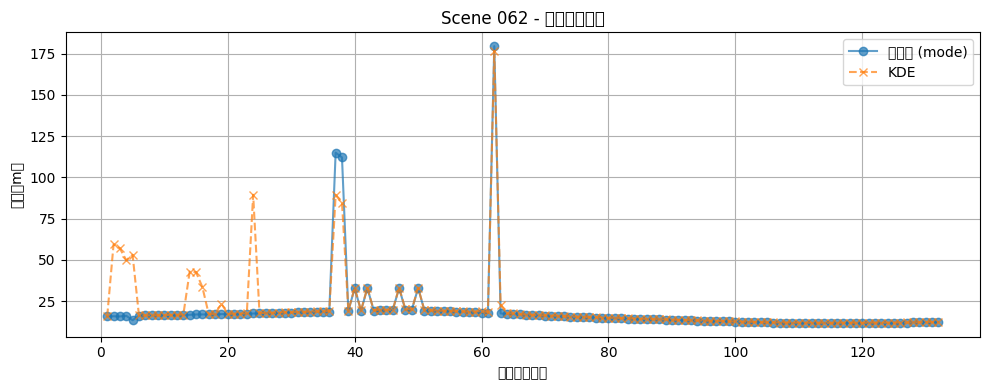

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# パス設定
OLD_PATH = "../testdistance_estimates.json"
NEW_PATH = "testdistance_kernel.json"
OUTPUT_DIR = "scene_comparison_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 読み込み
with open(OLD_PATH, encoding="utf-8") as f:
    old_data = json.load(f)
with open(NEW_PATH, encoding="utf-8") as f:
    new_data = json.load(f)

# 比較グラフをシーンごとに描画
for scene_id in sorted(old_data.keys()):
    if scene_id not in new_data:
        continue

    old_frames = old_data[scene_id]
    new_frames = new_data[scene_id]
    common_keys = sorted(set(old_frames.keys()) & set(new_frames.keys()))
    if len(common_keys) < 2:
        continue

    x = [int(f.replace("frame_", "")) for f in common_keys]
    y_old = [old_frames[f] for f in common_keys]
    y_new = [new_frames[f] for f in common_keys]

    plt.figure(figsize=(10, 4))
    plt.plot(x, y_old, label="最頻値 (mode)", marker='o', linestyle='-', alpha=0.7)
    plt.plot(x, y_new, label="KDE", marker='x', linestyle='--', alpha=0.7)
    plt.title(f"Scene {scene_id} - 距離推定比較")
    plt.xlabel("フレーム番号")
    plt.ylabel("距離（m）")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{scene_id}_comparison.png"))
    plt.close()

print(f"✅ グラフ出力完了: {len(os.listdir(OUTPUT_DIR))}件 → {OUTPUT_DIR}/ に保存")
